In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import linregress

# -----------------------------
# Load data
# -----------------------------
# file_path = "/home/falconnier/Documents/PPMI_study_data_starting_point/PPMI_Curated_Data_Cut_Public_20251112.xlsx"
file_path = "/home/falconnier/Documents/mri-preprocessing/csv_dir/PPMI_Curated_Data_Cut_Public_20251112.xlsx"
df = pd.read_excel(file_path)


In [2]:
print(df.columns.tolist())

['SITE', 'PATNO', 'COHORT', 'subgroup', 'enroll_phase', 'enroll_source', 'analytic_subgroup', 'HIQ_RBD', 'study_status', 'NSD_Status', 'NSD_STAGE', 'PRIMDIAG', 'OTHNEURO', 'EVENT_ID', 'YEAR', 'visit_date', 'age', 'age_at_visit', 'SEX', 'EDUCYRS', 'race', 'HISPLAT', 'ASHKJEW', 'AFICBERB', 'BASQUE', 'fampd', 'fampd_bin', 'handed', 'howlive', 'sex_orient', 'BMI', 'agediag', 'ageonset', 'duration', 'duration_yrs', 'DOMSIDE', 'sym_tremor', 'sym_rigid', 'sym_brady', 'sym_posins', 'sym_other', 'sym_unknown', 'PDTRTMNT', 'LEDD', 'age_datscan', 'age_LP', 'age_upsit', 'upsit', 'upsit_pctl', 'upsit_pctl15', 'moca', 'bjlot', 'DVS_JLO_MSSA', 'DVS_JLO_MSSAE', 'clockdraw', 'DVT_CLCKDRAW', 'DVZ_CLCKDRAW', 'hvlt_discrimination', 'hvlt_immediaterecall', 'hvlt_retention', 'HVLTFPRL', 'HVLTRDLY', 'HVLTREC', 'DVT_TOTAL_RECALL', 'DVT_DELAYED_RECALL', 'DVT_RETENTION', 'DVT_RECOG_DISC_INDEX', 'lexical', 'DVT_FAS', 'DVS_FAS', 'lns', 'DVS_LNS', 'MODBNT', 'DVS_BNT', 'PCTL_BNT', 'SDMTOTAL', 'DVT_SDM', 'DVSD_SDM',

Randomly selected patient: 100006


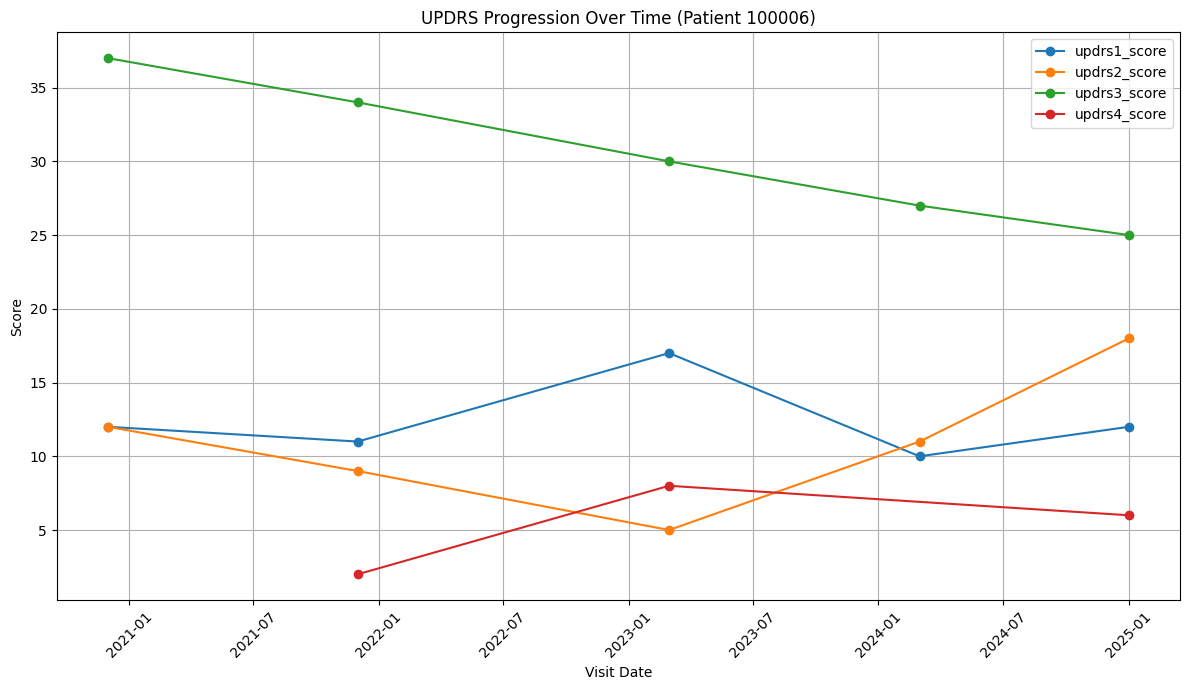

In [3]:
# -----------------------------
# Clean and format data
# -----------------------------

# Convert visit_date (format like "10/2020") to datetime
df["visit_date"] = pd.to_datetime(df["visit_date"], format="%m/%Y", errors="coerce")

# Drop rows with missing PATNO or visit_date
df = df.dropna(subset=["PATNO", "visit_date"])

# -----------------------------
# Select random patient
# -----------------------------
random_patient = np.random.choice(df["PATNO"].unique())
random_patient = 100006

df[df["subgroup"] != "Healthy Control"]
patient_df = df[df["PATNO"] == random_patient].copy()

# Sort by date
patient_df = patient_df.sort_values("visit_date")

print(f"Randomly selected patient: {random_patient}")

# -----------------------------
# Columns to plot
# -----------------------------
score_columns = [
    "updrs1_score",
    "updrs2_score",
    "updrs3_score",
    # "updrs3_score_on",
    "updrs4_score",
    # "updrs_totscore",
    # "updrs_totscore_on",
    # "hy",
    # "hy_on",
    # "NHY",
    # "NHY_ON",
]

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(12, 7))

for col in score_columns:
    if col in patient_df.columns:
        temp = patient_df[["visit_date", col]].dropna()
        if not temp.empty:
            plt.plot(temp["visit_date"], temp[col], marker="o", label=col)

plt.xlabel("Visit Date")
plt.ylabel("Score")
plt.title(f"UPDRS Progression Over Time (Patient {random_patient})")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


In [4]:
print(df["subgroup"].unique())

<StringArray>
[    'Sporadic PD',        'Hyposmia',            'PRKN', 'Healthy Control',
             'GBA',           'LRRK2',             'RBD',           'PINK1',
            'SNCA',      'PRKN + RBD',     'LRRK2 + GBA',     'LRRK2 + RBD',
       'GBA + RBD',           'SWEDD',       'Normosmic',   'LRRK2 + VPS35',
        'Other GV',     'PARK7 + RBD',   'LRRK2 + PINK1']
Length: 19, dtype: str


/tmp/ipykernel_98555/1194160806.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  patient_df["rel_years"] = (patient_df["visit_date"] - t0).dt.days / 365.25
/tmp/ipykernel_98555/1194160806.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  patient_df["rel_years"] = (patient_df["visit_date"] - t0).dt.days / 365.25
/tmp/ipykernel_98555/1194160806.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns

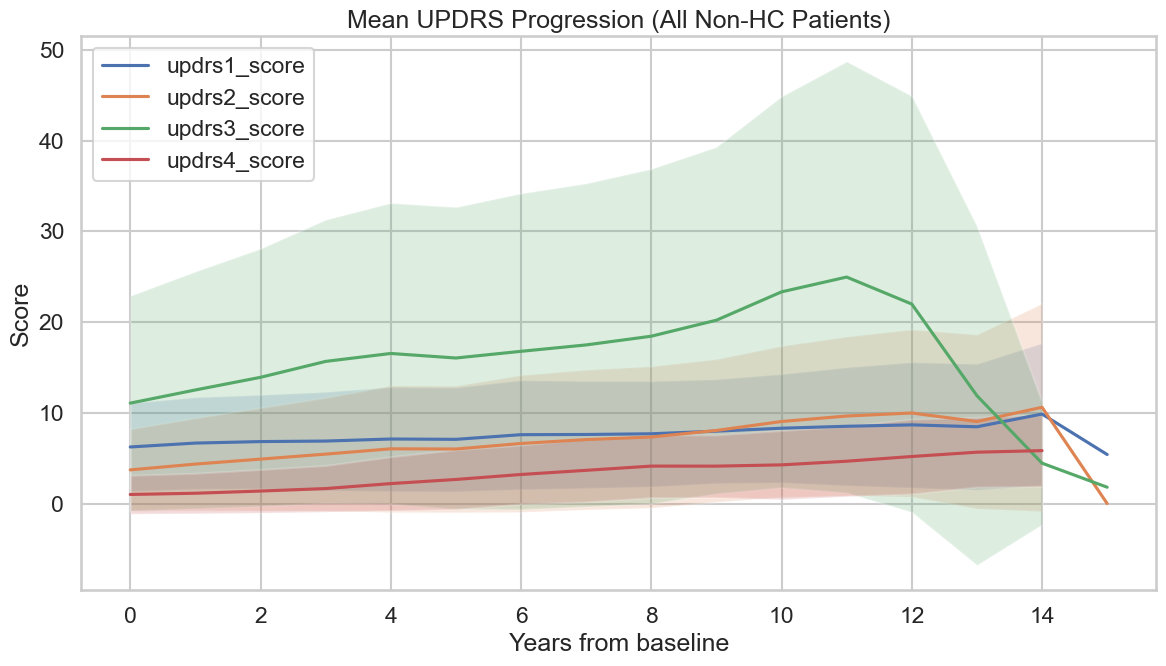


Mean yearly progression rates (points/year):
updrs1_score: 0.408
updrs2_score: 0.619
updrs3_score: 1.272
updrs4_score: 0.467


In [5]:
# Container for interpolated yearly data
all_interpolated = {col: [] for col in score_columns}
all_slopes = {col: [] for col in score_columns}

# -----------------------------
# Process each patient
# -----------------------------
for patno, patient_df in df.groupby("PATNO"):
    patient_df = patient_df.sort_values("visit_date")
    t0 = patient_df["visit_date"].min()

    patient_df["rel_years"] = (patient_df["visit_date"] - t0).dt.days / 365.25

    for col in score_columns:
        temp = patient_df[["rel_years", col]].dropna()

        if len(temp) >= 2:
            temp = temp.sort_values("rel_years")

            max_year = temp["rel_years"].max()
            yearly_grid = np.arange(0, np.floor(max_year) + 1, 1)

            if len(yearly_grid) < 2:
                continue

            interp_values = np.interp(yearly_grid, temp["rel_years"], temp[col])

            # Store interpolated values
            all_interpolated[col].append(
                pd.DataFrame({"year": yearly_grid, "score": interp_values})
            )

            # Store slope
            slope, _, _, _, _ = linregress(temp["rel_years"], temp[col])
            all_slopes[col].append(slope)

# -----------------------------
# Plot mean trajectories
# -----------------------------
sns.set(style="whitegrid", context="talk")
plt.figure(figsize=(12, 7))

for col in score_columns:
    if len(all_interpolated[col]) == 0:
        continue

    # Combine all patients
    combined = pd.concat(all_interpolated[col])

    # Compute mean per year
    mean_traj = combined.groupby("year")["score"].mean()
    std_traj = combined.groupby("year")["score"].std()

    years = mean_traj.index.values

    plt.plot(years, mean_traj.values, label=col)

    # Optional: shaded variability
    plt.fill_between(years, mean_traj - std_traj, mean_traj + std_traj, alpha=0.2)

plt.xlabel("Years from baseline")
plt.ylabel("Score")
plt.title("Mean UPDRS Progression (All Non-HC Patients)")
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# Print mean annual rates
# -----------------------------

print("\nMean yearly progression rates (points/year):")
for col in score_columns:
    if len(all_slopes[col]) > 0:
        mean_rate = np.mean(all_slopes[col])
        print(f"{col}: {mean_rate:.3f}")